In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pyneb as pn

import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.io import fits
from scipy.interpolate import Akima1DInterpolator
from scipy import optimize as opt
import sys
import emcee
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from astropy.table import Table
import matplotlib

import numpy as np
from astropy.io import fits
import time
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from scipy import signal
import matplotlib.pyplot as plt
import warnings

In [2]:
#mass_table = np.loadtxt("Stellar_Mass_Lipika_CEERS.txt",skip)
#close_matches = np.loadtxt("Close_Matches_ceers.txt",skiprows=1)
#close_matches

#pd.read_csv("Stellar_Mass_Lipika_CEERS.txt", sep = ' ', index_col = 0)
#pd.read_csv('Close_Matches_ceers.txt', sep = ' ', index_col = 0)

# stellar_mass = pd.read_csv("Stellar_Mass_Lipika_CEERS.txt", sep=' ',usecols =[0])
# stellar_mass.index.names = ['ID_CEERS']
# stellar_mass

# close_matches = pd.read_csv('Close_Matches_ceers.txt', sep=' ')
# close_matches

# stellar_mass = pd.read_csv("Stellar_Mass_Lipika_CEERS.txt", sep=' ',index_col = 0)
# close_matches = pd.read_csv('Close_Matches_ceers.txt', sep=' ')
# close_matches= close_matches.set_index('ID_ceers')
# matched_close_matches = close_matches.loc[stellar_mass.index.values] 
# matched_close_matches

# stellar_mass = pd.read_csv("Stellar_Mass_Lipika_CEERS.txt", sep=' ', index_col=0)
# close_matches = pd.read_csv('Close_Matches_ceers.txt', sep=' ', index_col='ID_ceers')
# stellar_mass['median_mass'] = stellar_mass.median(axis=1)
# stellar_mass.index = stellar_mass.index.map(str)  # Converting index to string if necessary
# close_matches.index = close_matches.index.map(str)
# matched_close_matches = close_matches.join(stellar_mass['median_mass'], how='inner')


#mass_table = pd.read_csv("mass_table.txt", sep=' ', index_col=1)
# main_table = Table.read('MAIN_TABLE_CORRECTED.fits')
# main_df = main_table.to_pandas()
# final_merged_table = pd.merge(main_df, mass_table, left_index=True, right_on='CAT_INDEX')
# final_merged_table.to_csv('mass_table.txt', sep=' ', index=True)
# final_merged_table

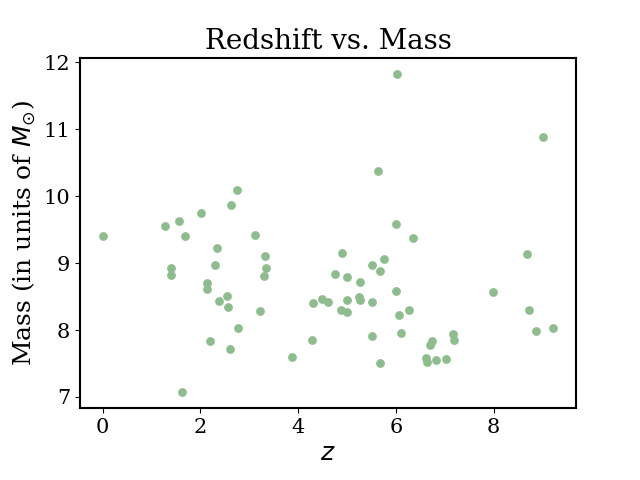

In [3]:
%matplotlib widget
matplotlib.style.use('paper')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5

final_table = pd.read_csv("mass_table.txt", sep=' ')

plt.figure()
plt.scatter(final_table['NEW_REDSHIFT_x'], final_table['median_mass'], color = 'darkseagreen',s = 28)
plt.xlabel('$z$')
plt.ylabel(r'Mass (in units of $M_{\odot}$)')
plt.title('Redshift vs. Mass')
plt.subplots_adjust(bottom=0.15) 
plt.savefig('mass_vs_redshift.pdf')

plt.show()

In [4]:
import pandas as pd

# Load the data from the CSV file
final_table = pd.read_csv('mass_table.txt', sep=' ')

# Define the bins for redshift
bins = [1, 2, 3, 4, 5, 6, 7, 8, 9]
labels = ['1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9']

# Bin the data
final_table['Redshift_bin'] = pd.cut(final_table['NEW_REDSHIFT_x'], bins=bins, labels=labels, right=False)

# Group the data by the bins and print out the redshifts and median_mass for each bin
for label in labels:
    print(f"\nRedshifts and median_mass in bin {label}:")
    bin_data = final_table[final_table['Redshift_bin'] == label][['NEW_REDSHIFT_x', 'median_mass']]
    for index, row in bin_data.iterrows():
        print(f"Redshift: {row['NEW_REDSHIFT_x']}, Median Mass: {row['median_mass']}")



Redshifts and median_mass in bin 1-2:
Redshift: 1.63347326563271, Median Mass: 7.073566295664385
Redshift: 1.676414689525719, Median Mass: 9.407013345416356
Redshift: 1.4075136405837148, Median Mass: 8.82682681938601
Redshift: 1.2784139894544002, Median Mass: 9.548614208723023
Redshift: 1.4019463891834665, Median Mass: 8.931619438932312
Redshift: 1.5673069995679074, Median Mass: 9.627186283487305

Redshifts and median_mass in bin 2-3:
Redshift: 2.1935641365790346, Median Mass: 7.836704383641285
Redshift: 2.57239846618318, Median Mass: 8.336566957407923
Redshift: 2.742487402043184, Median Mass: 10.090847339303435
Redshift: 2.374104386051384, Median Mass: 8.433415095017711
Redshift: 2.6126873267902586, Median Mass: 7.715087982431495
Redshift: 2.6367701537243, Median Mass: 9.872681973861049
Redshift: 2.771861051123002, Median Mass: 8.02509298581955
Redshift: 2.3376667925738515, Median Mass: 9.226494818747202
Redshift: 2.1444197344421387, Median Mass: 8.698432084628196
Redshift: 2.1373224

In [5]:
import pandas as pd

# Load the data from the CSV file
final_table = pd.read_csv('mass_table.txt', sep=' ')

# Define the bins for redshift
bins = [1, 2, 3, 4, 5, 6, 7, 8, 9]
labels = ['1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9']

# Bin the data
final_table['Redshift_bin'] = pd.cut(final_table['NEW_REDSHIFT_x'], bins=bins, labels=labels, right=False)

# Group the data by the bins and calculate the median of the median_mass in each bin
median_masses = final_table.groupby('Redshift_bin')['median_mass'].median()

# Print the median of median_mass for each redshift bin
for label, median in median_masses.items():
    print(f"Median of median_mass in bin {label}: {median}")


Median of median_mass in bin 1-2: 9.169316392174334
Median of median_mass in bin 2-3: 8.616891321572698
Median of median_mass in bin 3-4: 8.863233336891737
Median of median_mass in bin 4-5: 8.412725539169656
Median of median_mass in bin 5-6: 8.606391401570145
Median of median_mass in bin 6-7: 7.950335382894475
Median of median_mass in bin 7-8: 7.897964075399463
Median of median_mass in bin 8-9: 8.303152757893706


/var/folders/49/3nd_n851703bty_2dj98470h0000gn/T/ipykernel_29416/3981859575.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_masses = final_table.groupby('Redshift_bin')['median_mass'].median()


/var/folders/49/3nd_n851703bty_2dj98470h0000gn/T/ipykernel_29416/3542769563.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_masses = final_table.groupby('Redshift_bin')['median_mass'].median()


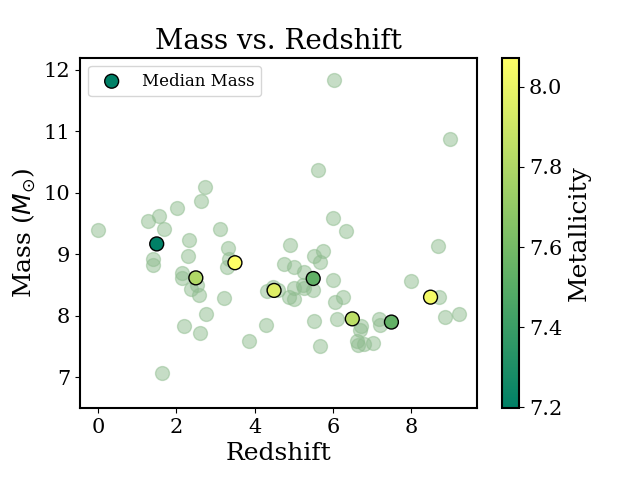

In [6]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt

# Load the data from the CSV file
final_table = pd.read_csv('mass_table.txt', sep=' ')

# Define the bins for redshift
bins = [1, 2, 3, 4, 5, 6, 7, 8, 9]
labels = ['1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9']

# Bin the data by redshift
final_table['Redshift_bin'] = pd.cut(final_table['NEW_REDSHIFT_x'], bins=bins, labels=labels, right=False)

# Group the data by the bins and calculate the median of the median_mass in each bin
median_masses = final_table.groupby('Redshift_bin')['median_mass'].median()

# Now load the metallicity data (50th percentile for each redshift bin)
files_list = sorted(glob.glob('bootstrap_metallicities/*.txt'))  # Sorted to ensure order matches bins

# Initialize list to store 50th percentiles (medians)
metallicities = []

# Loop through each file and calculate the 50th percentile
for file_path in files_list:
    # Load the data
    data = np.loadtxt(file_path)
    
    # Remove NaN values
    filtered_data = data[~np.isnan(data)]
    
    # Calculate the 50th percentile (median)
    median_metallicity = np.percentile(filtered_data, 50)
    metallicities.append(median_metallicity)

# Convert metallicities to a numpy array
metallicities = np.array(metallicities)

# Create a DataFrame for easy plotting
result_df = pd.DataFrame({
    'Redshift_Bin': median_masses.index,
    'Median_Mass': median_masses.values,
    'Metallicity': metallicities
})

# Map the midpoints for the redshift bins
redshift_midpoints = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]

# Create the plot
plt.figure()

# Plot all mass points from your original data
plt.scatter(final_table['NEW_REDSHIFT_x'], final_table['median_mass'], color='darkseagreen', alpha=0.5)

# Overlay median mass points colored by metallicity
sc = plt.scatter(redshift_midpoints, result_df['Median_Mass'], c=result_df['Metallicity'], cmap='summer', edgecolor='black', s=100, label='Median Mass')

# Adding a colorbar
plt.colorbar(sc, label='Metallicity')

# Set plot titles and labels
plt.title('Mass vs. Redshift')
plt.xlabel('Redshift')
plt.ylabel(r'Mass ($M_{\odot}$)') 
plt.subplots_adjust(bottom=0.15) 
plt.legend()
plt.ylim(6.5,12.2)  # Adjusted y-axis range
plt.savefig('mass_vs_redshift.pdf')

plt.show()
